# 04 · Competitor landscape from PubMed counts

**Why this notebook exists.** The competition section of the business case
says that nobody sells an H&E-to-molecular product for sarcoma and that the
sarcoma AI literature is prognosis-first. A reviewer should be able to check
both claims. This notebook counts PubMed records with the public E-utilities
API ([NCBI E-utilities](https://www.ncbi.nlm.nih.gov/books/NBK25499/)) for a
small set of stated queries and draws one figure with four panels.

Keyword counts over titles and abstracts are a coarse instrument: categories
overlap, and a paper can match a query without doing what the query names.
The figure is a map of where effort goes, not a systematic review.

| Panel | Question | Query family |
|---|---|---|
| A | How fast is sarcoma AI growing | sarcoma AND (deep learning OR machine learning OR artificial intelligence), by year |
| B | What does sarcoma AI work on | the same, intersected with task keywords |
| C | Where is H&E-to-molecular prediction published | whole-slide or histopathology AND deep learning AND (mutation OR fusion OR molecular OR biomarker) prediction, by tumour type |
| D | Who sells it, for which tumour | the regulated products listed in the business case, section 9 |

## 1 · Setup

**Story.** One helper that asks PubMed for a count, with a one-second pause so
we stay under the unauthenticated rate limit of three requests a second.

In [1]:
import time                         # 暫停，守 NCBI 的速率限制
from pathlib import Path

import requests                     # 打 E-utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm

HERE = Path.cwd()
FIG = HERE / "figures"
OUT = HERE.parent / "business"      # 圖給 business case 用

ESEARCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"


def pubmed_count(term):
    # 回傳符合查詢的 PubMed 記錄數，只要 count 不要清單
    r = requests.get(ESEARCH, params={"db": "pubmed", "term": term, "retmode": "json"}, timeout=60)
    r.raise_for_status()
    time.sleep(0.4)
    return int(r.json()["esearchresult"]["count"])


AI = '("deep learning" OR "machine learning" OR "artificial intelligence" OR "neural network")'
SARCOMA = '(sarcoma OR osteosarcoma OR liposarcoma OR leiomyosarcoma OR "Ewing" OR "synovial sarcoma" OR chondrosarcoma OR rhabdomyosarcoma)'
print("test:", pubmed_count(f"{SARCOMA} AND {AI} AND 2024[dp]"), "sarcoma AI records in 2024")

test: 208 sarcoma AI records in 2024


**Output.** One live count, to show the helper works and that the queries are
being answered by PubMed now, not from a cache.

## 2 · Panel A, sarcoma AI papers per year

**Story.** The same query for each publication year from 2018 to 2025, and a
denominator of all cancer AI papers so the sarcoma share can be read.

In [2]:
YEARS = list(range(2018, 2026))
rows = []
for year in tqdm(YEARS, desc="by year"):
    rows.append({
        "year": year,
        "sarcoma_ai": pubmed_count(f"{SARCOMA} AND {AI} AND {year}[dp]"),
        "cancer_ai": pubmed_count(f"(cancer OR neoplasm OR tumour OR tumor) AND {AI} AND {year}[dp]"),
    })
by_year = pd.DataFrame(rows)
by_year["sarcoma_share_pct"] = 100 * by_year["sarcoma_ai"] / by_year["cancer_ai"]
by_year

by year:   0%|          | 0/8 [00:00<?, ?it/s]

,year,sarcoma_ai,cancer_ai,sarcoma_share_pct
0,2018,20,1758,1.137656
1,2019,35,3188,1.097867
2,2020,58,5036,1.151708
3,2021,106,7304,1.451260
4,2022,139,9398,1.479038
5,2023,132,11589,1.139011
6,2024,208,14816,1.403888
7,2025,270,20951,1.288721


**Output.** Sarcoma AI records per year and their share of all cancer AI
records. The share tells us whether sarcoma is keeping up with the field or
falling behind it.

## 3 · Panel B, what sarcoma AI works on

**Story.** The sarcoma AI query intersected with one task keyword set at a
time, 2018 to 2026. Categories overlap. The one we care about, molecular or
fusion prediction from histology, is listed last on purpose so the reader
sees how thin it is.

In [3]:
TASKS = {
    "Radiology (MRI, CT, PET)": '(MRI OR "magnetic resonance" OR CT OR "computed tomography" OR PET OR radiomics)',
    "Histology diagnosis or subtype": '(histopathology OR histology OR "whole slide" OR "H&E" OR pathology) AND (diagnosis OR classification OR subtype)',
    "Prognosis or survival": '(prognosis OR survival OR recurrence OR metastasis)',
    "Treatment response": '("treatment response" OR chemotherapy OR "neoadjuvant" OR radiotherapy)',
    "Segmentation": '(segmentation)',
    "Genomics without images": '(genomic OR transcriptomic OR "gene expression" OR RNA-seq) NOT (histopathology OR "whole slide" OR MRI OR CT)',
    "Molecular or fusion from H&E": '(histopathology OR histology OR "whole slide" OR "H&E") AND (fusion OR mutation OR molecular OR genomic OR biomarker OR MDM2 OR "gene expression")',
}
task_counts = {}
for name, kw in tqdm(TASKS.items(), desc="tasks"):
    task_counts[name] = pubmed_count(f"{SARCOMA} AND {AI} AND {kw} AND 2018:2026[dp]")
tasks = pd.Series(task_counts).sort_values(ascending=False)
tasks

tasks:   0%|          | 0/7 [00:00<?, ?it/s]

Prognosis or survival             537
Histology diagnosis or subtype    400
Radiology (MRI, CT, PET)          346
Treatment response                263
Molecular or fusion from H&E      251
Segmentation                      144
Genomics without images           137
dtype: int64

**Output.** Records per task, 2018 to 2026. Prognosis and diagnosis lead;
the molecular-from-H&E count is an upper bound because the keyword set is
broad, and few of those papers predict a fusion gene, which is the clinical
target here.

## 4 · Panel C, H&E-to-molecular prediction by tumour type

**Story.** The same "molecular from histology with deep learning" query, run
once per tumour type. If the category is mature in breast, colorectal, lung and
prostate and nearly empty in sarcoma, the whitespace claim holds.

In [4]:
HE_MOL = f'{AI} AND (histopathology OR "whole slide" OR "H&E" OR "hematoxylin") AND (fusion OR mutation OR "molecular subtype" OR biomarker OR "gene expression" OR "microsatellite") AND 2018:2026[dp]'
TUMOURS = {
    "Breast": "breast",
    "Colorectal": "(colorectal OR colon OR rectal)",
    "Lung": "lung",
    "Prostate": "prostate",
    "Gastric": "(gastric OR stomach)",
    "Brain glioma": "(glioma OR glioblastoma)",
    "Sarcoma": SARCOMA,
}
tumour_counts = {}
for name, kw in tqdm(TUMOURS.items(), desc="tumours"):
    tumour_counts[name] = pubmed_count(f"{kw} AND {HE_MOL}")
tumours = pd.Series(tumour_counts).sort_values(ascending=False)
tumours

tumours:   0%|          | 0/7 [00:00<?, ?it/s]

Breast          1692
Lung            1620
Colorectal      1098
Brain glioma     716
Prostate         672
Gastric          429
Sarcoma          182
dtype: int64

**Output.** Records per tumour type for H&E-to-molecular deep learning. The
sarcoma bar is the one to compare with the rest.

## 5 · Panel D, regulated products by tumour type

**Story.** Not a PubMed query. This is the product table from the business
case, section 9, drawn as a grid: companies down the side, tumour types along
the top, a filled cell where a CE, UKCA or FDA-cleared H&E-to-molecular
product exists. Sources are in that section. The sarcoma column is empty.

In [5]:
PRODUCTS = pd.DataFrame(
    [
        ["Owkin, MSIntuit CRC", 0, 1, 0, 0, 0],
        ["Panakeia, PANProfiler", 1, 0, 0, 0, 0],
        ["Paige, Biomarker Suite", 0, 0, 0, 1, 0],
        ["Paige Predict (Tempus), research use", 1, 1, 1, 1, 0],
    ],
    columns=["Product", "Breast", "Colorectal", "Lung", "Prostate", "Sarcoma"],
).set_index("Product")
PRODUCTS

,Breast,Colorectal,Lung,Prostate,Sarcoma
Product,,,,,
"Owkin, MSIntuit CRC",0,1,0,0,0
"Panakeia, PANProfiler",1,0,0,0,0
"Paige, Biomarker Suite",0,0,0,1,0
"Paige Predict (Tempus), research use",1,1,1,1,0


**Output.** Four rows, five tumour columns. Paige Predict covers many tumour
types as a research-use panel; the regulated products are single-tumour.

## 6 · The figure

**Story.** Four panels on one page in the same style as the care-pathway
landscape figure in the executive summary: grey for context, red for the
whitespace that this submission targets.

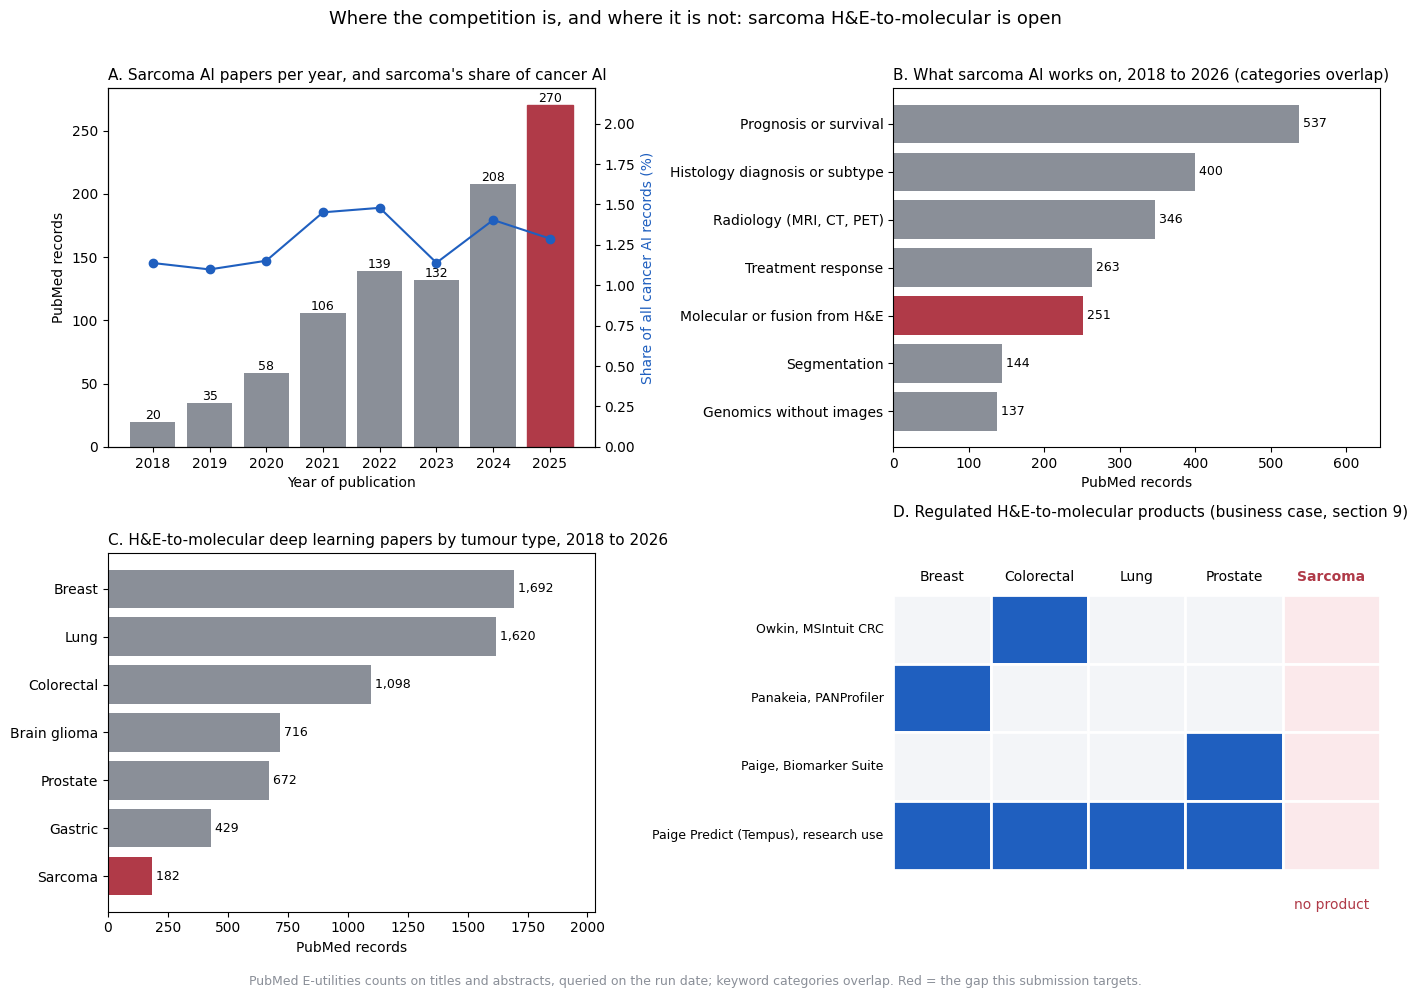

In [6]:
GREY, RED, BLUE = "#8a8f98", "#b03a48", "#1f5fbf"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A 年度趨勢
ax = axes[0, 0]
bars = ax.bar(by_year["year"], by_year["sarcoma_ai"], color=GREY)
bars[-1].set_color(RED)
for b, v in zip(bars, by_year["sarcoma_ai"]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax2 = ax.twinx()
ax2.plot(by_year["year"], by_year["sarcoma_share_pct"], "o-", color=BLUE)
ax2.set_ylabel("Share of all cancer AI records (%)", color=BLUE)
ax2.set_ylim(0, max(2, by_year["sarcoma_share_pct"].max() * 1.5))
ax.set_title("A. Sarcoma AI papers per year, and sarcoma's share of cancer AI", loc="left", fontsize=11)
ax.set_xlabel("Year of publication")
ax.set_ylabel("PubMed records")

# B 任務分布
ax = axes[0, 1]
order = tasks.sort_values()
colors = [RED if "Molecular" in n else GREY for n in order.index]
ax.barh(order.index, order.values, color=colors)
for i, v in enumerate(order.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_title("B. What sarcoma AI works on, 2018 to 2026 (categories overlap)", loc="left", fontsize=11)
ax.set_xlabel("PubMed records")
ax.set_xlim(0, order.max() * 1.2)

# C 腫瘤別比較
ax = axes[1, 0]
order = tumours.sort_values()
colors = [RED if n == "Sarcoma" else GREY for n in order.index]
ax.barh(order.index, order.values, color=colors)
for i, v in enumerate(order.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_title("C. H&E-to-molecular deep learning papers by tumour type, 2018 to 2026", loc="left", fontsize=11)
ax.set_xlabel("PubMed records")
ax.set_xlim(0, order.max() * 1.2)

# D 產品矩陣
ax = axes[1, 1]
ax.set_xlim(0, PRODUCTS.shape[1]); ax.set_ylim(-0.6, PRODUCTS.shape[0] + 0.6)
for i, (prod, row) in enumerate(PRODUCTS.iterrows()):
    for j, col in enumerate(PRODUCTS.columns):
        face = BLUE if row[col] else "#f3f5f8"
        if col == "Sarcoma":
            face = "#fbe9eb"
        ax.add_patch(Rectangle((j, PRODUCTS.shape[0] - 1 - i), 1, 1, facecolor=face, edgecolor="white", lw=2))
    ax.text(-0.1, PRODUCTS.shape[0] - 0.5 - i, prod, ha="right", va="center", fontsize=9)
for j, col in enumerate(PRODUCTS.columns):
    ax.text(j + 0.5, PRODUCTS.shape[0] + 0.15, col, ha="center", va="bottom", fontsize=10,
            color=RED if col == "Sarcoma" else "black", weight="bold" if col == "Sarcoma" else "normal")
ax.text(PRODUCTS.shape[1] - 0.5, -0.4, "no product", ha="center", va="top", fontsize=10, color=RED)
ax.axis("off")
ax.set_title("D. Regulated H&E-to-molecular products (business case, section 9)", loc="left", fontsize=11, pad=26)

plt.suptitle("Where the competition is, and where it is not: sarcoma H&E-to-molecular is open", fontsize=13)
plt.figtext(0.5, 0.005, "PubMed E-utilities counts on titles and abstracts, queried on the run date; keyword categories overlap. Red = the gap this submission targets.",
            ha="center", fontsize=9, color=GREY)
plt.tight_layout(rect=(0, 0.02, 1, 0.97))
plt.savefig(FIG / "fig9_competitor_landscape.png", dpi=150)
plt.savefig(OUT / "fig_competitor_landscape.png", dpi=150)
plt.show()

**Output.** Figure 9, saved to `technical/figures/` and `business/`. Panel A
is growth, B is where sarcoma effort goes, C is where the H&E-to-molecular
category lives, D is who sells it. Read C and D together: the category is
mature in breast, lung and colorectal, an order of magnitude smaller in
sarcoma, and no regulated product exists for sarcoma.

## 7 · Queries, verbatim

Printed so a reviewer can paste them into PubMed.

In [7]:
print("A:", f"{SARCOMA} AND {AI} AND <year>[dp]")
for name, kw in TASKS.items():
    print("B:", name, "=", f"{SARCOMA} AND {AI} AND {kw} AND 2018:2026[dp]")
for name, kw in TUMOURS.items():
    print("C:", name, "=", f"{kw} AND {HE_MOL}")
pd.concat([by_year.set_index("year")], axis=1).to_csv(HERE / "data" / "landscape_by_year.csv")
tasks.to_csv(HERE / "data" / "landscape_tasks.csv")
tumours.to_csv(HERE / "data" / "landscape_tumours.csv")

A: (sarcoma OR osteosarcoma OR liposarcoma OR leiomyosarcoma OR "Ewing" OR "synovial sarcoma" OR chondrosarcoma OR rhabdomyosarcoma) AND ("deep learning" OR "machine learning" OR "artificial intelligence" OR "neural network") AND <year>[dp]
B: Radiology (MRI, CT, PET) = (sarcoma OR osteosarcoma OR liposarcoma OR leiomyosarcoma OR "Ewing" OR "synovial sarcoma" OR chondrosarcoma OR rhabdomyosarcoma) AND ("deep learning" OR "machine learning" OR "artificial intelligence" OR "neural network") AND (MRI OR "magnetic resonance" OR CT OR "computed tomography" OR PET OR radiomics) AND 2018:2026[dp]
B: Histology diagnosis or subtype = (sarcoma OR osteosarcoma OR liposarcoma OR leiomyosarcoma OR "Ewing" OR "synovial sarcoma" OR chondrosarcoma OR rhabdomyosarcoma) AND ("deep learning" OR "machine learning" OR "artificial intelligence" OR "neural network") AND (histopathology OR histology OR "whole slide" OR "H&E" OR pathology) AND (diagnosis OR classification OR subtype) AND 2018:2026[dp]
B: Progn

**Output.** The exact strings, plus three CSV files under `data/` so the
numbers in the figure can be re-checked without rerunning the queries.